In [1]:
'''Use the Iris dataset (or dataset provided by the instructor).
Q6. Import all necessary Python libraries required for:
a) Data handling
b) Data preprocessing
c) Model building
d) Model evaluation'''


'Use the Iris dataset (or dataset provided by the instructor).\nQ6. Import all necessary Python libraries required for:\na) Data handling\nb) Data preprocessing\nc) Model building\nd) Model evaluation'

In [4]:
import pandas as pd 
import numpy as np 

# to load data 
from sklearn.datasets import load_iris
iris= load_iris()
df=pd.DataFrame(iris.data,columns=iris.feature_names)
df["target"]=iris.target

# to preprocess data 
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
X=df.drop("target",axis=1)
y=df["target"]
X_train,X_test,y_train,y_test=train_test_split(
    X,y,test_size=0.2,random_state=42)
scaler=StandardScaler()
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)

from sklearn.linear_model import LinearRegression 
model=LinearRegression()
model.fit(X_train,y_train)







,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [13]:
import pandas as pd 
import numpy as np 
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression 
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report 
from sklearn.datasets import fetch_california_housing

housing = fetch_california_housing()
X=housing.data
y=housing.target
df=pd.DataFrame(X,columns=housing.feature_names)
df["Price"]=y

scaler=StandardScaler()
X=scaler.fit_transform(X)

X_train,X_test,y_train,y_test = train_test_split(
    X,y,test_size=0.2,random_state=42)

class LinearRegressionScratch:
    def __init__(self, lr=0.01, epochs=1000):
        self.lr=lr
        self.epochs=epochs
    def fit(self,X,y):
        n,m=X.shape
        self.W=np.zeros(m)
        self.b=0
        for _ in range (self.epochs):
            y_pred=np.dot(X,self.W)+ self.b
            dw=(-2/n)*np.dot(X.T,(y-y_pred))
            db=(-2/n)*np.sum(y-y_pred)

            self.W-=self.lr*dw
            self.b-=self.lr*db
    def predict(self,X):
        return np.dot(X,self.W)+self.b
        
    
model=LinearRegressionScratch()
from sklearn.linear_model import LinearRegression 
model=LinearRegression()
model.fit(X_train,y_train)
y_pred=model.predict(X_test)
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
print("MAE", mean_absolute_error(y_test,y_pred))
print("MSE", mean_squared_error(y_test,y_pred))
print("R2 score", r2_score(y_test,y_pred))

#decision tree classifier
X_train,X_test,y_train,y_test = train_test_split(
    X,y,test_size=0.2,random_state=42)
model=DecisionTreeClassifier(max_depth=2,random_state=42)
model.fit(X_train,y_train)
import matplotlib.pyplot as plt 
plt.figure(figsize=(12,8))
plot_tree(model,
          feature_names=iris.feature.names,
          class_names=iris.target_names,
          filled=True)
plt.show()
y_pred=model.predict(X_test)
#accuracy metrics 
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report 
print("Accuracy score", accuracy_score(y_test,y_pred))
print("Confusion matrix", confusion_matrix(y_test,y_pred))
print("Classification report", classification_report(y_test,y_pred))

#cross validation 
from sklearn.model_selection import cross_val_score
scores=cross_val_score(model,X,y,cv=5)
print("cross validation score",scores)
print("mean accuracy", scores.mean())
print("standard deviation", scores.std())

# decision tree regressor 
from sklearn.tree import DecisionTreeRegressor 
model=DecisionTreeRegressor(random_state=42)
model.fit(X_train,y_train)




MAE 0.5332001304956566
MSE 0.5558915986952444
R2 score 0.5757877060324508


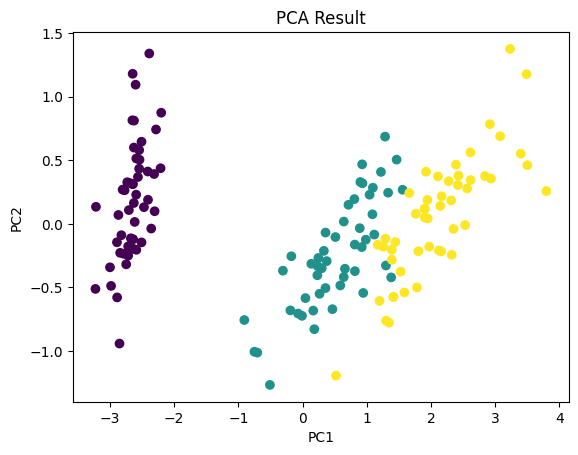

Explained Variance: [0.92461872 0.05306648]
Total Variance Retained: 0.9776852063187963


In [14]:
#PCA
import matplotlib.pyplot as plt 
from sklearn.decomposition import PCA
from sklearn.datasets import load_iris
data=load_iris()
X=data.data
y=data.target
pca=PCA(n_components=2)
X_pca=pca.fit_transform(X)
# Plot transformed data
plt.scatter(X_pca[:,0], X_pca[:,1], c=y)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA Result")
plt.show()
# Variance retained
print("Explained Variance:", pca.explained_variance_ratio_)
print("Total Variance Retained:", sum(pca.explained_variance_ratio_))



In [17]:
#ann
import numpy as np 
import pandas as pd 
from sklearn.neural_network import MLPClassifier
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
# Dataset
X, y = make_classification(n_samples=500, n_features=4)
# Split
X_train, X_test, y_train, y_test = train_test_split(X, y)
# ANN model
model = MLPClassifier(hidden_layer_sizes=(8,), max_iter=500)
# Train
model.fit(X_train, y_train)
# Accuracy
print("Accuracy:", model.score(X_test, y_test))

Accuracy: 0.912


In [18]:
# bpnn
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# Step 1: Create dataset (classification problem)
X, y = make_classification(n_samples=500, n_features=4, random_state=42)

# Step 2: Split into training and testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Step 3: Build Neural Network (Input + Hidden + Output)
model = Sequential()

# Hidden layer (input layer automatically handled)
model.add(Dense(6, activation='relu', input_shape=(4,)))

# Output layer (binary classification)
model.add(Dense(1, activation='sigmoid'))

# Step 4: Compile model (defines backpropagation setup)
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Step 5: Train model (Backpropagation happens here)
history = model.fit(X_train, y_train, epochs=30, batch_size=10)

# Step 6: Plot training loss vs epochs
plt.plot(history.history['loss'])
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training Loss vs Epochs")
plt.show()

# Step 7: Evaluate model accuracy
loss, accuracy = model.evaluate(X_test, y_test)
print("Accuracy:", accuracy)

ModuleNotFoundError: No module named 'tensorflow'